## 00 Import

In [71]:
import random
import requests
from datetime import datetime
import time
import json
import os
from dotenv import load_dotenv
import pandas as pd
import logging
from pathlib import Path
from tqdm import tqdm
from stock_api import Buy_Stock, Sell_Stock, Get_User_Stocks
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Noto Sans CJK SC'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
log_path = Path("/app/logs/error.log")
log_path.parent.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler()
    ],
    force=True,
)

ACCOUNT = os.getenv('STOCK_ACCOUNT_USERNAME')
PASSWORD = os.getenv('STOCK_ACCOUNT_PASSWORD')
PG_URI = os.getenv('POSTGRES_URI')
CATEGORY_TABLE = 'model_comparison_per_category'
STOCK_TABLE = 'model_comparison_per_stock'

In [72]:
stock_dict_path = '/app/data/topk_stocks_by_industries.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

print(f"Stock industry: {stock_dict.keys()}")

Stock industry: dict_keys(['ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業'])


## 01 Plot Model Prediction performance

### 01-1 Data Preprocess

In [73]:
def fetch_single_stock_price(stock_code: str):
    sql = f"""
    SELECT *
    FROM "daily_info_{stock_code}"
    ORDER BY date ASC
    """
    try:
        df = pd.read_sql(sql, PG_URI)
        return df
    except Exception as e:
        logging.error(f"Error fetching stock price for {stock_code}: {e}")
        return None
    
def fetch_industry_stock_prices(industry: str):
    if industry not in stock_dict:
        logging.error(f"Industry '{industry}' not found in stock dictionary.")
        return None
    
    stock_codes = stock_dict[industry]
    industry_data = []
    
    for code in tqdm(stock_codes, desc=f"Fetching prices for {industry}"):
        df = fetch_single_stock_price(code)
        if df is not None:
            industry_data.append(df)
        else:
            logging.error(f"Failed to fetch data for stock code: {code}")
    industry_df = pd.concat(industry_data, ignore_index=True)
    return industry_df


In [74]:
# ── Fetch Data ──────────────────────────────────────────────────────────
# 修改此處以切換產業
selected_industry = '半導體業'

raw_df = fetch_industry_stock_prices(selected_industry)
print(f"Fetched {len(raw_df)} rows for {selected_industry}")
print(f"Stocks: {sorted(raw_df['stock_code_id'].unique())}")
raw_df.head()

Fetching prices for 半導體業: 100%|██████████| 13/13 [00:00<00:00, 17.50it/s]


Fetched 18603 rows for 半導體業
Stocks: ['2303', '2330', '2337', '2344', '2408', '2449', '2454', '3054', '3189', '3661', '3711', '6854', '8162']


,date,stock_code_id,market,capacity,turnover,open,high,low,close,change,transaction_volume,close_is_proxy
0,2020-01-02,2303,TWSE,32937461,544863192,16.45,16.65,16.40,16.55,0.10,5382,False
1,2020-01-03,2303,TWSE,48588354,792990409,16.55,16.55,16.15,16.30,-0.25,9541,False
2,2020-01-06,2303,TWSE,44790472,719002202,16.05,16.15,15.95,16.05,-0.25,5041,False
3,2020-01-07,2303,TWSE,39718117,633334895,16.05,16.15,15.80,16.00,-0.05,7401,False
4,2020-01-08,2303,TWSE,60494690,954618728,15.85,15.90,15.65,15.75,-0.25,9368,False


In [75]:
import sys
sys.path.insert(0, "/app/model")
from feature_engineering import build_features, create_sequences

# build_features 回傳寬表格及 scaler，供 baseline model 和 LSTM 直接使用
(
    X_train, X_test,
    y_train, y_test,
    df_train, df_test,
    x_scaler, y_scaler,
    feature_cols, target_cols, close_wide,
) = build_features(raw_df, test_start="2026-05-12")

print(f"Train: {df_train.shape}, Test: {df_test.shape}")
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")
print(f"Target stocks: {target_cols}")
df_train.tail()

Train: (1540, 119), Test: (23, 119)
Features: 119, Targets: 13
Target stocks: ['ret_2303', 'ret_2330', 'ret_2337', 'ret_2344', 'ret_2408', 'ret_2449', 'ret_2454', 'ret_3054', 'ret_3189', 'ret_3661', 'ret_3711', 'ret_6854', 'ret_8162']


,close_2303,close_2330,close_2337,close_2344,close_2408,close_2449,close_2454,close_3054,close_3189,close_3661,...,rel_close_2344,rel_close_2408,rel_close_2449,rel_close_2454,rel_close_3054,rel_close_3189,rel_close_3661,rel_close_3711,rel_close_6854,rel_close_8162
date,,,,,,,,,,,,,,,,,,,,,
2026-05-05,83.1,2250.0,160.5,98.8,256.5,354.0,3155.0,67.1,527.0,4150.0,...,-811.469231,-653.769231,-556.269231,2244.730769,-843.169231,-383.269231,3239.730769,-390.269231,-750.769231,-858.269231
2026-05-06,91.4,2250.0,172.0,108.5,282.0,328.5,3430.0,73.8,482.5,4565.0,...,-854.153846,-680.653846,-634.153846,2467.346154,-888.853846,-480.153846,3602.346154,-438.653846,-808.653846,-909.853846
2026-05-07,96.5,2310.0,164.5,114.0,287.0,339.0,3420.0,75.5,492.5,4795.0,...,-873.976923,-700.976923,-648.976923,2432.023077,-912.476923,-495.476923,3807.023077,-447.976923,-834.476923,-931.776923
2026-05-08,91.3,2290.0,153.0,107.0,274.0,311.0,3630.0,70.4,458.0,4890.0,...,-892.415385,-725.415385,-688.415385,2630.584615,-929.015385,-541.415385,3890.584615,-483.415385,-852.415385,-944.715385
2026-05-11,95.0,2235.0,159.5,117.5,301.0,299.5,3880.0,69.6,503.0,5375.0,...,-941.930769,-758.430769,-759.930769,2820.569231,-989.830769,-556.430769,4315.569231,-522.430769,-913.930769,-1004.430769


In [76]:
# close_wide 是 build_features 的最後一個回傳值
ret_wide = close_wide.pct_change().dropna()
# columns 名稱是 "close_2330" → 需要對齊 baseline 期望的欄位格式
ret_wide.columns = [c.replace("close_", "") for c in ret_wide.columns]
ret_wide.head()

,2303,2330,2337,2344,2408,2449,2454,3054,3189,3661,3711,6854,8162
date,,,,,,,,,,,,,
2020-01-03,-0.015106,0.001475,0.000000,0.012723,-0.013953,-0.023560,-0.015855,-0.035026,-0.009709,-0.049793,-0.012077,0.0,0.0
2020-01-06,-0.015337,-0.022091,0.025000,-0.022613,-0.012972,-0.033512,-0.024166,-0.003630,-0.037255,0.008734,-0.037897,0.0,0.0
2020-01-07,-0.003115,-0.007530,-0.034660,-0.020566,-0.031063,0.005548,0.004717,0.005464,-0.023422,-0.038961,0.000000,0.0,0.0
2020-01-08,-0.015625,0.000000,0.023936,0.002625,0.018496,0.001379,0.010563,-0.012681,0.000000,-0.022523,-0.016518,0.0,0.0
2020-01-09,0.019048,0.024279,-0.003896,0.010471,0.009685,0.019284,0.015099,0.009174,0.001043,0.023041,0.031008,0.0,0.0


In [77]:
def get_baseline_preds(ret: pd.Series, test_start: str):
    train = ret[ret.index < test_start]
    test  = ret[ret.index >= test_start]
    preds = {}
    preds["Naive"] = ret.shift(1).reindex(test.index)
    preds["MA(5)"] = ret.rolling(window=5).mean().shift(1).reindex(test.index)
    from statsmodels.tsa.ar_model import AutoReg
    ar_model = AutoReg(pd.Series(train.values, dtype=float), lags=5).fit()
    y_ar = ar_model.predict(start=len(train), end=len(train) + len(test) - 1)
    preds["AR(5)"] = pd.Series(y_ar.values, index=test.index)
    return preds


import types
import mlflow
import torch
import socket
from feature_engineering import create_sequences

from LSTM import LSTMModel
_fake_pkg = types.ModuleType("model")
_fake_mod = types.ModuleType("model.LSTM")
_fake_mod.LSTMModel = LSTMModel
sys.modules.setdefault("model", _fake_pkg)
sys.modules["model.LSTM"] = _fake_mod

try:
    _ip = socket.gethostbyname("mlflow")
    mlflow.set_tracking_uri(f"http://{_ip}:5000")
except socket.gaierror:
    mlflow.set_tracking_uri("http://localhost:5000")


def get_latest_lstm_run_id(category: str) -> str:
    client = mlflow.MlflowClient()
    all_runs = client.search_runs("0", max_results=300, order_by=["start_time DESC"])
    pipeline_run = next(
        r for r in all_runs
        if r.info.run_name.startswith("pipeline_")
        and not r.data.tags.get("mlflow.parentRunId")
    )
    cat_run = next(
        r for r in all_runs
        if r.data.tags.get("mlflow.parentRunId") == pipeline_run.info.run_id
        and r.info.run_name == category
    )
    leaf_run = next(
        r for r in all_runs
        if r.data.tags.get("mlflow.parentRunId") == cat_run.info.run_id
    )
    return leaf_run.info.run_id


def get_lstm_preds(
    category: str,
    close_wide: pd.DataFrame,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_scaler,
    df_test: pd.DataFrame,
    seq_len: int = 20,
) -> dict:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    run_id = get_latest_lstm_run_id(category)
    model = mlflow.pytorch.load_model(f"runs:/{run_id}/best_LSTM", map_location=device)
    model.eval()

    # 用 train 最後 seq_len 筆當 warm-up，拼上整個 X_test
    # 這樣 create_sequences 產出的每一筆都對應一個 test 日期
    X_combined = np.concatenate([X_train[-seq_len:], X_test], axis=0)
    X_seq, _ = create_sequences(X_combined, X_combined, seq_len)
    # X_seq.shape == (len(X_test), seq_len, n_features)

    X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred_scaled = model(X_tensor).cpu().numpy()

    pred_ret = y_scaler.inverse_transform(pred_scaled)

    stock_codes = [c.replace("close_", "") for c in close_wide.columns]
    return {
        code: pd.Series(pred_ret[:, i], index=df_test.index)
        for i, code in enumerate(stock_codes)
    }


In [78]:
def ret_to_price(close_series: pd.Series, ret_pred: pd.Series) -> pd.Series:
    """
    close_series: 完整的 close 時間序列（含 train + test）
    ret_pred:     test 期間的預測報酬率
    還原邏輯：price(t) = close(t-1) * (1 + ret_pred(t))
    """
    # 取 test 期間每天的「前一日收盤」作為基準
    prev_close = close_series.shift(1).reindex(ret_pred.index)
    return prev_close * (1 + ret_pred)


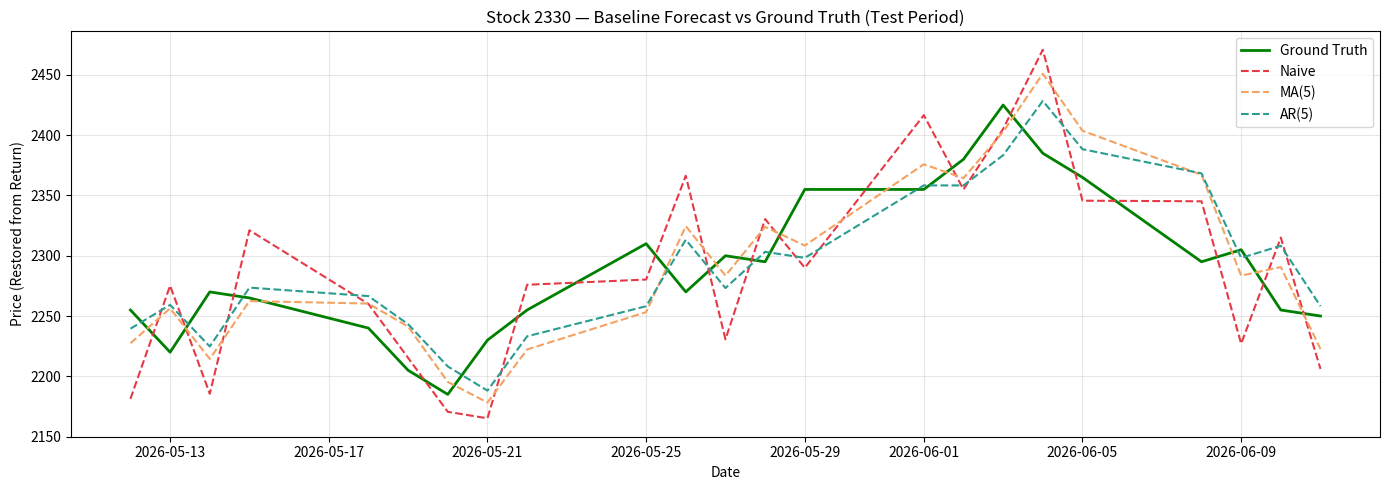

In [79]:
import matplotlib.pyplot as plt

def plot_baseline_predictions(stock_code: str, close_wide, ret_wide, test_start: str):
    col = f"close_{stock_code}"
    close = close_wide[col]
    ret   = ret_wide[stock_code]
    
    # ground truth（test 期間收盤價）
    test_close = close[close.index >= test_start]
    
    preds = get_baseline_preds(ret, test_start)
    
    colors = {"Naive": "#E63946", "MA(5)": "#F4A261", "AR(5)": "#2A9D8F"}
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_close.index, test_close.values, color="green", lw=2, label="Ground Truth")
    
    for name, ret_pred in preds.items():
        price_pred = ret_to_price(close, ret_pred)
        ax.plot(price_pred.index, price_pred.values,
                color=colors[name], lw=1.5, linestyle="--", label=name)
    
    ax.set_title(f"Stock {stock_code} — Baseline Forecast vs Ground Truth (Test Period)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (Restored from Return)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 呼叫
plot_baseline_predictions("2330", close_wide, ret_wide, test_start="2026-05-12")


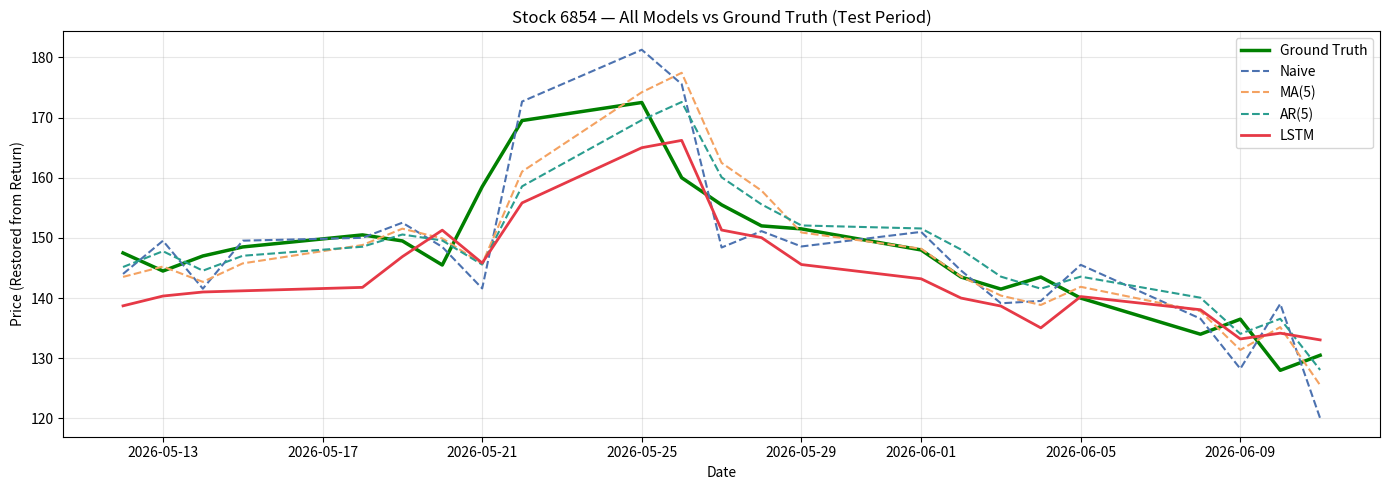

In [90]:
def plot_all_predictions(stock_code: str, close_wide, df_test,
                         baseline_preds, lstm_preds, test_start: str):
    col = f'close_{stock_code}'
    close = close_wide[col]
    test_close = close[close.index >= test_start]

    colors = {
        'Naive':   '#4C72B0',
        'MA(5)':   '#F4A261',
        'AR(5)':   '#2A9D8F',
        'LSTM':    '#E63946',
    }

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_close.index, test_close.values,
            color='green', lw=2.5, label='Ground Truth')

    # Baseline
    for name, ret_pred in baseline_preds.items():
        price_pred = ret_to_price(close, ret_pred.dropna())
        ax.plot(price_pred.index, price_pred.values,
                color=colors[name], lw=1.5, linestyle='--', label=name)

    # LSTM
    if stock_code in lstm_preds:
        ret_pred = lstm_preds[stock_code].dropna()
        price_pred = ret_to_price(close, ret_pred)
        ax.plot(price_pred.index, price_pred.values,
                color=colors['LSTM'], lw=2, linestyle='-', label='LSTM')

    ax.set_title(f'Stock {stock_code} — All Models vs Ground Truth (Test Period)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (Restored from Return)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_all_predictions(
    stock_code="6854",
    close_wide=close_wide,
    df_test=df_test,
    baseline_preds=get_baseline_preds(ret_wide["6854"], test_start="2026-05-12"),
    lstm_preds=get_lstm_preds("半導體業", close_wide, X_train, X_test, y_scaler, df_test),
    test_start="2026-05-12"
)

## 02 Model Performance

In [ ]:
df_eval_category = pd.read_sql(f"SELECT * FROM {CATEGORY_TABLE}", PG_URI)
df_eval_stock = pd.read_sql(f"SELECT * FROM {STOCK_TABLE}", PG_URI)

In [91]:
df_eval_stock[df_eval_stock['stock_code']=='6854']

,model,train_r2,train_rmse,test_r2,test_rmse,test_mae,test_hit_rate,pred_mean_ret,actual_mean_ret,next_day_pred_ret,stock_code,run_date,category,train_start,train_end,test_start,test_end
153,Naive,-0.861998,0.034697,-0.706763,0.047285,0.036793,0.521739,-0.005362,-0.00407,0.019531,6854,2026-06-12,半導體業,2020-01-01,2026-05-11,2026-05-12,2026-06-12
154,MA(5),-0.193860,0.027819,-0.168147,0.039118,0.029779,0.521739,-0.004688,-0.00407,-0.018266,6854,2026-06-12,半導體業,2020-01-01,2026-05-11,2026-05-12,2026-06-12
155,AR(5),0.009750,0.025336,-0.021004,0.036572,0.028991,0.391304,0.000393,-0.00407,-0.002892,6854,2026-06-12,半導體業,2020-01-01,2026-05-11,2026-05-12,2026-06-12
170,LSTM,0.654919,0.014966,0.190442,0.037642,0.029538,0.687500,-0.012453,-0.00407,-0.007666,6854,2026-06-12,半導體業,2020-01-01,2026-05-11,2026-05-12,2026-06-12


/tmp/ipykernel_1695/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_1695/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_1695/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_1695/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_1695/707469830.py:15: UserWarning: set_ticklabels() should on

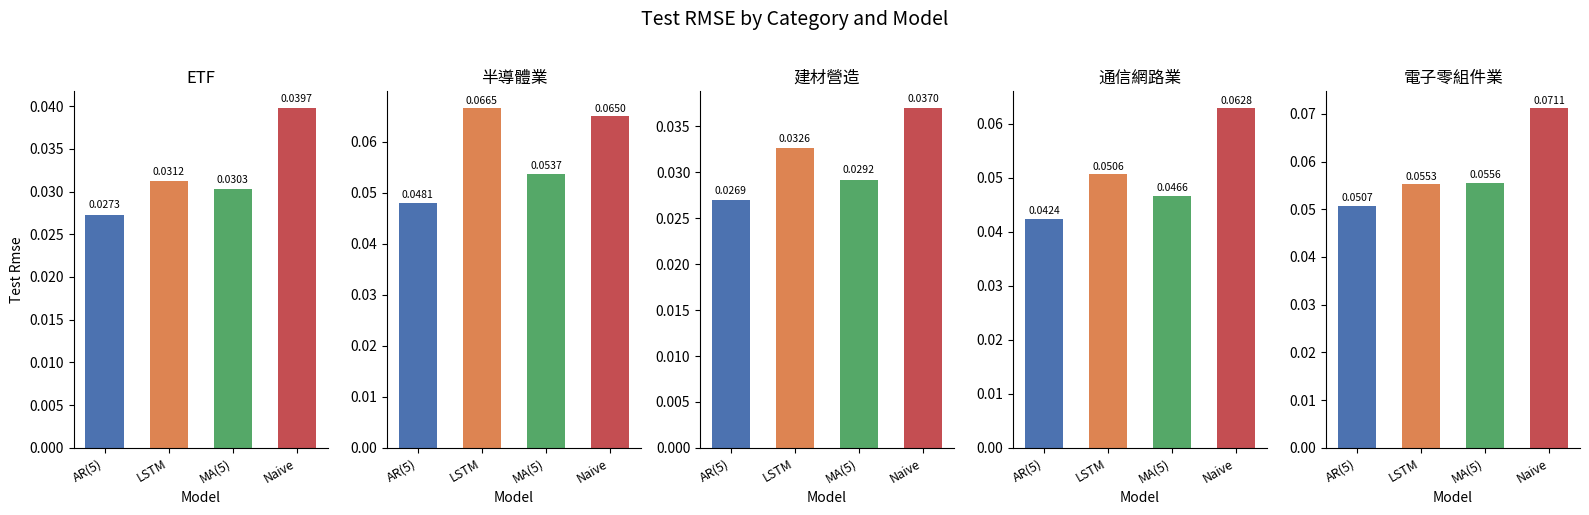

In [ ]:
# View model performance by category
def plot_comparison_by_category(df_eval_category, target_col:str, title:str):
    categories = df_eval_category['category'].unique()
    models = df_eval_category['model'].unique()
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(1, len(categories), figsize=(16, 5), sharey=False)

    for ax, category in zip(axes, categories):
        subset = df_eval_category[df_eval_category['category'] == category].set_index('model')
        vals = [subset.loc[m, target_col] if m in subset.index else 0 for m in models]
        bars = ax.bar(models, vals, color=colors, width=0.6)
        ax.set_title(category, fontsize=12)
        ax.set_xlabel('Model')
        ax.set_ylabel(target_col.replace('_', ' ').title() if ax == axes[0] else '')
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_comparison_by_category(df_eval_category, 'test_rmse', 'Test RMSE by Category and Model')


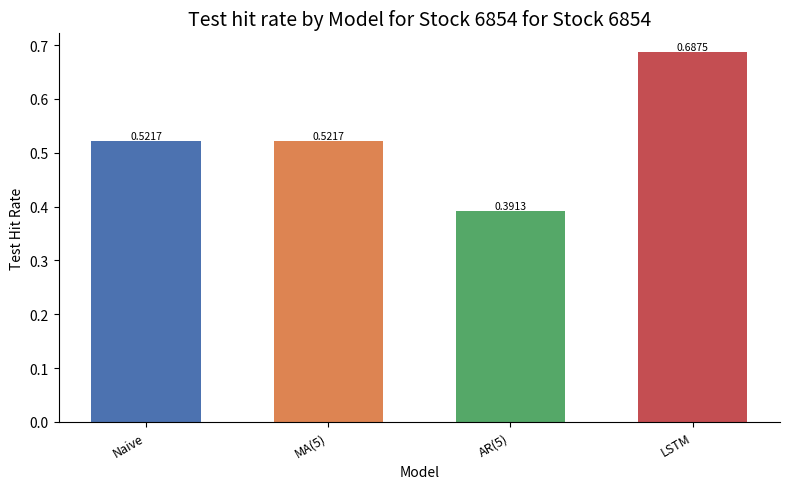

In [88]:
# View model performance by stock
def plot_comparison_by_stock(df_eval_stock, target_col:str, stock_code: str, title:str):
    subset = df_eval_stock[df_eval_stock['stock_code'] == stock_code].set_index('model')
    models = subset.index.tolist()
    vals = subset[target_col].tolist()
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(models, vals, color=colors, width=0.6)
    plt.title(f"{title} for Stock {stock_code}", fontsize=14)
    plt.xlabel('Model')
    plt.ylabel(target_col.replace('_', ' ').title())
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    for bar, val in zip(bars, vals):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    plt.tight_layout()
    plt.show()

inspected_stock_code = '6854'
plot_comparison_by_stock(df_eval_stock, 'test_hit_rate', inspected_stock_code, f'Test hit rate by Model for Stock {inspected_stock_code}')

In [87]:
df_eval_stock[(df_eval_stock['test_hit_rate']>0.5) & (df_eval_stock['model']=='LSTM')]

,model,train_r2,train_rmse,test_r2,test_rmse,test_mae,test_hit_rate,pred_mean_ret,actual_mean_ret,next_day_pred_ret,stock_code,run_date,category,train_start,train_end,test_start,test_end
30,LSTM,0.809197,0.010338,0.038730,0.023624,0.018865,0.5625,0.008214,0.001528,0.014277,0050,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
31,LSTM,0.753075,0.013417,0.061047,0.022447,0.017977,0.5625,0.007299,0.001116,0.006093,0052,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
33,LSTM,0.601229,0.023016,-0.078432,0.046604,0.036871,0.6250,0.017124,0.001523,0.045966,00631L,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
35,LSTM,0.634974,0.005445,-0.015515,0.024744,0.021935,0.5625,0.008820,0.005092,0.018393,00878,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
36,LSTM,0.642759,0.004994,-0.101053,0.021883,0.018227,0.6250,0.004608,0.007106,0.013463,00919,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
37,LSTM,0.821786,0.001717,0.002154,0.024718,0.021327,0.6250,0.007965,0.001390,0.017839,009816,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
38,LSTM,0.603936,0.004758,0.047514,0.030527,0.025232,0.6250,0.009383,0.000436,0.020762,00981A,2026-06-12,ETF,2020-01-01,2026-05-11,2026-05-12,2026-06-12
72,LSTM,0.680973,0.011646,-0.862937,0.043393,0.026076,0.6250,-0.014270,-0.001224,-0.008888,2515,2026-06-12,建材營造,2020-01-01,2026-05-11,2026-05-12,2026-06-12
73,LSTM,0.580830,0.009425,-0.148542,0.021994,0.019112,0.5625,-0.001007,0.008884,0.002651,2535,2026-06-12,建材營造,2020-01-01,2026-05-11,2026-05-12,2026-06-12
75,LSTM,0.702930,0.008840,-0.145295,0.020795,0.015735,0.5625,-0.007867,0.003892,-0.004251,2542,2026-06-12,建材營造,2020-01-01,2026-05-11,2026-05-12,2026-06-12


## END